#Growth and Margin Sit in Different Microsoft Segments, FY2019 to FY2024

*FY2024 operating margin was 44.6%. Although calm its three segments have a 21% point gap on margin and 15% point gap on growth. The growth and margin ranking behind this finding from the 10 k filings are built and exports clean tables for the Power BI dashboard to read.*

**Scope:** FY2019-2024 six years on one segment definition. *Microsoft restated its reportable segments effective FY2025, extending past FY2024 would mix two incompatible definitions.

**What This Does:** loads the transcribed 10-k figured, reshapes them from wide to long, computes operating margin and revenue growth, checks that the segments reconcile to company totals, ploting the quadrant and exporting two CSVs.

**Notes:** Microsoft reports R&D and Capital Expenditure company wide only.

##**Section 1: Load and Reshape**
The source is hand transcribed from the SEC's Microsoft 10 K filings (FY2019-2024). The 'Source Filing' column records which filing each row came from. Each year was reconciled with the following as filings have the previous year's values.

A Company table is split out and the data is transformed from wide to long. The seg_map dictionary lists each segment once and tells the code which revenue and operating income columns belong to that segment. This allows the reshape step to process all three segments using one reusable method instead of writing almost identical code three times.

Expected after this cell: *segment table 18 rows, company table 6 rows.*



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()
xlsx = "10k_Microsoft_Segment_Data.xlsx"
raw = pd.read_excel(xlsx, sheet_name="10k Microsoft Segment Data", skiprows=1)
raw.columns = raw.columns.str.strip()

print(f"RAW Shape: {raw.shape} (Expect six rows, one per year)")
print(raw.dtypes)
print(raw.head())

company = raw[["Year", "Total Revenue", "Total Operating Income"]].copy()
company.columns = ["fiscal_year", "total_revenue_musd", "total_operating_income_musd"]

seg_map = {
          "Productivity & Business Processes": ("Segment Rev (Prod. and Business Processes)",
                                                "Segment Operating Income (Prod. and Business Processes)"),
          "Intelligent Cloud":                 ("Segment Rev (Cloud)",
                                                "Segment Operating Income (Cloud)"),
          "More Personal Computing":           ("Segment Rev (Personal Computing)",
                                                "Segment Operating Income (Personal Computing)"),
      }
seg = pd.concat([
    pd.DataFrame({
        "fiscal_year":raw["Year"],
        "segment": name,
        "revenue_musd":raw[rev_col],
        "operating_income_musd":raw[inc_col],
    })
    for name, (rev_col, inc_col) in seg_map.items()
], ignore_index=True)

print(f"\nSEG Shape: {seg.shape} (Expect 18 rows = six years x three segments)")
print(seg.dtypes)
print(seg.sort_values(["segment","fiscal_year"]).head(8))
print(f"\nCompany:\n{company}")


Saving 10k_Microsoft_Segment_Data.xlsx to 10k_Microsoft_Segment_Data.xlsx
RAW Shape: (6, 11) (Expect six rows, one per year)
Year                                                       int64
Segment Rev (Prod. and Business Processes)                 int64
Segment Operating Income (Prod. and Business Processes)    int64
Segment Rev (Cloud)                                        int64
Segment Operating Income (Cloud)                           int64
Segment Rev (Personal Computing)                           int64
Segment Operating Income (Personal Computing)              int64
Total Revenue                                              int64
Total Operating Income                                     int64
R&D Expense                                                int64
Capital Expenditure                                        int64
dtype: object
   Year  Segment Rev (Prod. and Business Processes)  \
0  2019                                       41160   
1  2020                             

## **Section 2: Compute and Reconcile**

**Operating Margin** is operation incomes divided by revenue per segment per year. **Revenue Growth** is year over year change within each segment. The data is sorted by segment then year before 'pct_change()' runs, without sorting it may compare with different segments.

**Growth is Averaged While Margin is Not** The quadrant uses a three year average on the growth axis and single year on its margin axis.

Margin tends to move slowly so FY2024 represents it faily, while growth can be volatile. Ex. Personal Computing fell 8.7% in FY2023 and recounded 13.3% in FY2024, ranking it above Productivity on growth and reversing the bottom two segments, leading to a different recommendation. Averaging FY2022-24 reflects the segment's actual tragectory rather than a bounce off one bad year.

**The Reconciliation**
Two checks, three segment revenues and three segment operating incomes, both reconciling with the company total values.

**Limitations of Check**
The data provided does not give information about reallocation between segments, therefore the reconciliation is blind to any shifts the company makes as the total of all segments remains the same.

In [2]:
seg["operating_margin"] = seg["operating_income_musd"]/seg["revenue_musd"]
seg = seg.sort_values(["segment","fiscal_year"]).reset_index(drop=True)
seg["revenue_growth"] = seg.groupby("segment")["revenue_musd"].pct_change()
recent_years = sorted(seg["fiscal_year"].unique())[-3:]
growth_3yr_avg = (
    seg[seg["fiscal_year"].isin(recent_years)]
    .groupby("segment")["revenue_growth"]
    .mean()
    .rename("growth_3yr_avg")
    .reset_index()
)
seg = seg.merge(growth_3yr_avg, on="segment", how="left")
print(growth_3yr_avg)
print(seg.round(3))

#Reconcile Segment Totals Against Company Totals
check = (seg.groupby("fiscal_year")["revenue_musd"].sum()
.rename("segment_sum")
.to_frame()
.join(company.set_index("fiscal_year")["total_revenue_musd"]))
check["gap"] = check["total_revenue_musd"] - check["segment_sum"]
check["gap_pct"] = check["gap"]/check["total_revenue_musd"]
print(check.round(3))

check_oi = (seg.groupby("fiscal_year")["operating_income_musd"].sum()
.rename("segment_oi_sum")
.to_frame()
.join(company.set_index("fiscal_year")["total_operating_income_musd"]))
check_oi["gap"] = check_oi["total_operating_income_musd"] - check_oi["segment_oi_sum"]
print(check_oi)


                             segment  growth_3yr_avg
0                  Intelligent Cloud        0.206319
1            More Personal Computing        0.051526
2  Productivity & Business Processes        0.130188
    fiscal_year                            segment  revenue_musd  \
0          2019                  Intelligent Cloud         38985   
1          2020                  Intelligent Cloud         48366   
2          2021                  Intelligent Cloud         60080   
3          2022                  Intelligent Cloud         74965   
4          2023                  Intelligent Cloud         87907   
5          2024                  Intelligent Cloud        105362   
6          2019            More Personal Computing         45698   
7          2020            More Personal Computing         48251   
8          2021            More Personal Computing         54093   
9          2022            More Personal Computing         59941   
10         2023            More Personal

##**Section 3: Charts and Exports**

These charts are part of the analysis. Leading to a clearer understanding of the data, once the analysis is complete then the two cvs's are exported and uploaded to PowerBI for visualization and communication.  

**Chart 1: Segment Revenue Over Time**
Three lines following each segment's revenue from FY2019-FY2024 establish their scale before any judgements are made. Most notably, Intelligent Cloud overtakes the other two segments in FY2020 by 115 M and continues to pull away onward.


**Chart 2: The Quadrant**
This is the chart where the recommendation rests on. It shows not which is biggest but which is best positioned. The three year average revenue growth's relationship with FY2024 operating average results in the three segments being placed within four quadrants. These reference lines are established by average of the three segments and the segments positions within these reflect where the next dollar relative to the others should be allocated. These quadrant give the recommendation to Invest, Defend, Scrutinise, or Watch each segment.

*Note: The two axes use different time windows on purpose. As margin moves slowly, a one year representation sufficies while growth tends to be more volitile. To combat this averaging three years gives a fairer representation*

**The Results:** Cloud sits clearly on the top right of the chart (Invest), Personal Computing bottom left (Scrutinise), while Productivity is on the upper section while almost being exactly on the vertical line (Defend).

**The Spread Check:** The growth and margin spread is 15.5 and 21.0 points, this shows the need for the quadrants is there. If the three segments clustered together there would be no meaningful difference and the framing would collapse.


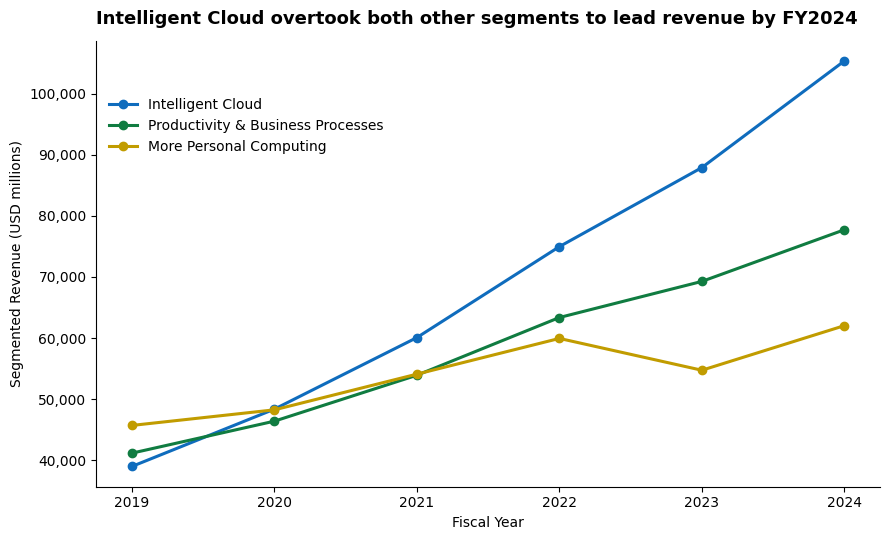

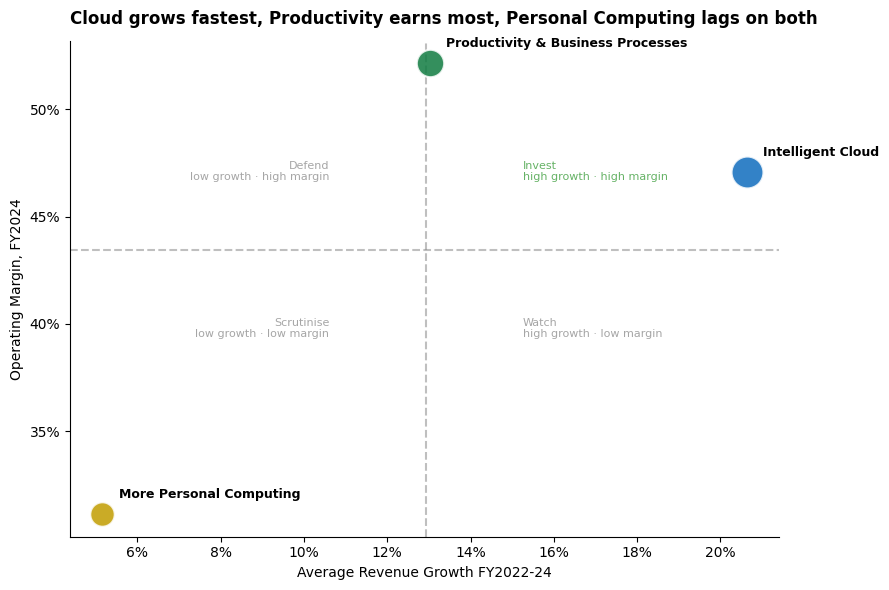

                                   growth  margin
segment                                          
Intelligent Cloud                   0.206   0.471
Productivity & Business Processes   0.130   0.522
More Personal Computing             0.052   0.311

Growth spread: 15.5 pts
Margin spread: 21.0 pts


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import os
from matplotlib.ticker import FuncFormatter
os.makedirs("images", exist_ok=True)

seg_order = ["Intelligent Cloud","Productivity & Business Processes","More Personal Computing"]
colours = {"Intelligent Cloud":"#0F6CBD",
           "Productivity & Business Processes":"#107C41",
           "More Personal Computing":"#C19C00"}
fig, ax = plt.subplots(figsize=(9, 5.5))

for name in seg_order:
  g = seg[seg["segment"] == name].sort_values("fiscal_year")
  ax.plot(g["fiscal_year"],g["revenue_musd"],
          marker = "o", linewidth=2.2, color=colours[name], label=name)

ax.set_title("Intelligent Cloud overtook both other segments to lead revenue by FY2024",
             fontsize=13, fontweight="bold",loc="left",pad=12)

ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Segmented Revenue (USD millions)")
ax.set_xticks(sorted(seg["fiscal_year"].unique()))

ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f"{v:,.0f}"))

ax.legend(frameon=False, loc="upper left", bbox_to_anchor = (0,0.90))
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("images/segment_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


# Ploting Quadrant and Verifying Spread
growth = (seg[seg["fiscal_year"] >= 2022]
          .groupby("segment")["revenue_growth"].mean())

margin = seg[seg["fiscal_year"]==2024].set_index("segment")["operating_margin"]
margin_label = "Operating Margin, FY2024"

pts = pd.DataFrame({"growth":growth,"margin":margin}).reindex(seg_order)
fig,ax = plt.subplots(figsize=(9,6))

gx, gy = pts["growth"].mean(), pts["margin"].mean()
ax.axvline(gx, ls="--",color="grey",alpha=0.5)
ax.axhline(gy, ls="--", color="grey",alpha=0.5)

xlo, xhi = pts["growth"].min(),pts["growth"].max()
ylo, yhi = pts["margin"].min(),pts["margin"].max()
pad_x, pad_y = (xhi-xlo)*0.15 or 0.02, (yhi-ylo)*0.15 or 0.02
ax.text(gx+pad_x, gy+pad_y, "Invest\nhigh growth · high margin",
        fontsize=8, color="green", alpha=0.6, ha="left", va="bottom")
ax.text(gx-pad_x,gy+pad_y, "Defend\nlow growth · high margin",
        fontsize=8, color="grey",alpha=0.7,ha="right",va="bottom")
ax.text(gx+pad_x,gy-pad_y, "Watch\nhigh growth · low margin",
        fontsize=8, color="grey", alpha=0.7, ha="left", va="top")
ax.text(gx-pad_x, gy-pad_y, "Scrutinise\nlow growth · low margin",
        fontsize=8, color="grey", alpha=0.7, ha="right", va="top")

rev2024 = seg[seg["fiscal_year"]==2024].set_index("segment")["revenue_musd"].reindex(seg_order)
for name in seg_order:
  ax.scatter(pts.loc[name, "growth"],pts.loc[name,"margin"],
             s=rev2024[name]/200,color=colours[name],alpha=0.85,
             edgecolor="white",linewidth=1.5,zorder=3)
  ax.annotate(name,(pts.loc[name, "growth"], pts.loc[name,"margin"]),
              xytext=(12,12), textcoords = "offset points", fontsize=9, fontweight="bold")

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.set_xlabel("Average Revenue Growth FY2022-24")
ax.set_ylabel(margin_label)

ax.set_title("Cloud grows fastest, Productivity earns most, Personal Computing lags on both",
             fontsize=12, fontweight="bold",loc="left",pad=12)

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("images/quadrant.png", dpi=150, bbox_inches="tight")
plt.show()

print(pts.round(3))
print("\nGrowth spread:", round((pts['growth'].max()-pts['growth'].min())*100, 1), "pts")
print("Margin spread:", round((pts['margin'].max()-pts['margin'].min())*100, 1), "pts")

seg.to_csv("microsoft_segments_analysed.csv", index=False)
files.download("microsoft_segments_analysed.csv")
company.to_csv("microsoft_company.csv", index=False)
files.download("microsoft_company.csv")